WARNING Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
🔍 Đang thực hiện nhận diện với mô hình ONNX...
Loading C:\Users\sonng\Code\APPAutoVRS\BE-AutoVRS\models\best.onnx for ONNX Runtime inference...
Using ONNX Runtime CPUExecutionProvider

image 1/1 C:\Users\sonng\Code\APPAutoVRS\BE-AutoVRS\Image_output\ai_processed_20250815_152239.jpg: 640x640 1 khuyetmach, 17.1ms
Speed: 2.3ms preprocess, 17.1ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)
✅ Nhận diện hoàn tất!


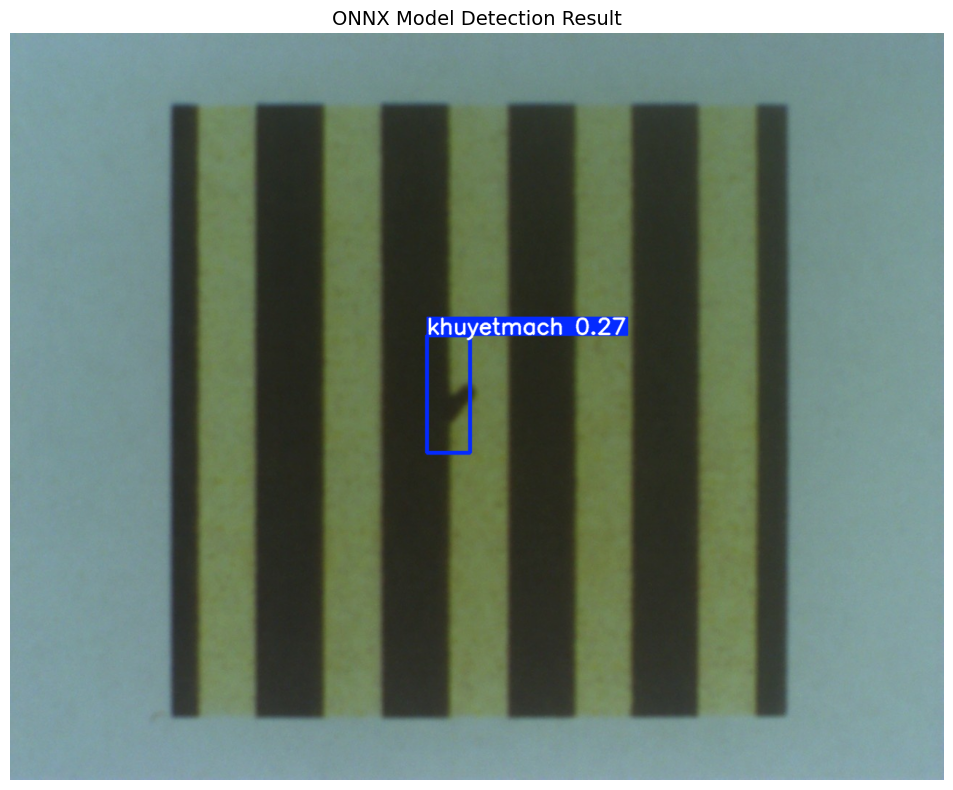


📊 Chi tiết các đối tượng được phát hiện:
📌 Đối tượng 1:
   - Class: khuyetmach (ID: 0)
   - Độ tin cậy (Confidence): 0.267
   - Tọa độ [x1, y1, x2, y2]: [572, 414, 630, 575]
--------------------------------------------------
✅ Đã lưu ảnh kết quả tại: /home/jkl0909/Test/onnx_detection_result.jpg

📈 Tổng số đối tượng phát hiện được: 1


In [1]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Load model ONNX với Ultralytics
model = YOLO(r'C:\Users\sonng\Code\APPAutoVRS\BE-AutoVRS\models\best.onnx')

# Đường dẫn ảnh cần nhận diện
image_path = r'C:\Users\sonng\Code\APPAutoVRS\BE-AutoVRS\Image_output\ai_processed_20250815_152239.jpg'

# Thực hiện nhận diện với mô hình ONNX
print("🔍 Đang thực hiện nhận diện với mô hình ONNX...")
results = model(image_path, conf=0.25, iou=0.45)
print("✅ Nhận diện hoàn tất!")

# Vẽ kết quả lên ảnh
annotated_image_bgr = results[0].plot()

# Chuyển ảnh từ BGR (OpenCV) sang RGB (Matplotlib)
annotated_image_rgb = cv2.cvtColor(annotated_image_bgr, cv2.COLOR_BGR2RGB)

# Hiển thị ảnh kết quả
plt.figure(figsize=(12, 8))
plt.imshow(annotated_image_rgb)
plt.axis('off')
plt.title("ONNX Model Detection Result", fontsize=14)
plt.tight_layout()
plt.show()

# Hiển thị thông tin chi tiết về các đối tượng được phát hiện
print("\n📊 Chi tiết các đối tượng được phát hiện:")
print("="*50)

# Lấy thông tin boxes từ kết quả
boxes = results[0].boxes

if len(boxes) == 0:
    print("Không phát hiện đối tượng nào!")
else:
    for i, box in enumerate(boxes):
        class_id = int(box.cls[0])
        class_name = model.names[class_id]  # Lấy tên class từ model
        confidence = float(box.conf[0])
        # Lấy tọa độ dạng [x1, y1, x2, y2]
        coords = [round(x) for x in box.xyxy[0].tolist()]

        print(f"📌 Đối tượng {i+1}:")
        print(f"   - Class: {class_name} (ID: {class_id})")
        print(f"   - Độ tin cậy (Confidence): {confidence:.3f}")
        print(f"   - Tọa độ [x1, y1, x2, y2]: {coords}")
        print("-"*50)

# Lưu ảnh kết quả
output_path = '/home/jkl0909/Test/onnx_detection_result.jpg'
cv2.imwrite(output_path, annotated_image_bgr)
print(f"✅ Đã lưu ảnh kết quả tại: {output_path}")

# So sánh số lượng phát hiện từ mô hình ONNX
print(f"\n📈 Tổng số đối tượng phát hiện được: {len(boxes)}")